# HomeValue — guided clinic and student workspace

This notebook has two modes:

1. **Guided clinic:** run the prepared cells, predict what will happen, inspect the evidence, and make a model decision.
2. **Exercise continuation:** extend the analysis and prepare the final submission after class.

[Read the complete Exercise 01 brief](https://github.com/lathrahul/modern-ai-ml-exercises/tree/main/exercise-01-homevalue) before continuing beyond the clinic. Sections 1–8 are the guided clinic; Section 9 begins the independent exercise continuation.

During the clinic, you are not expected to write the full modeling workflow from scratch. Your job is to connect the business question, model output, error pattern, and decision. Do not delete the AI-use disclosure.

## Clinic roadmap

By the end of the clinic, you should be able to:

- identify the row, target, prediction moment, and permitted inputs;
- compare a median baseline, simple regression, and multiple regression on the same validation homes;
- interpret a coefficient using units and conditional language;
- identify one residual or segment risk; and
- recommend **advance simple**, **advance multiple**, or **require more evidence**.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 40)
RANDOM_STATE = 42

In [2]:
# Use local files when the repository has been cloned. When this notebook is
# opened directly in Colab, load the same versioned files from GitHub.
local_data_dirs = [Path('../data'), Path('data'), Path('exercise-01-homevalue/data')]
data_dir = next((path for path in local_data_dirs if (path / 'train.csv').exists()), None)

if data_dir is not None:
    train_source = data_dir / 'train.csv'
    test_source = data_dir / 'test.csv'
    source_label = str(data_dir.resolve())
else:
    base_url = ('https://raw.githubusercontent.com/lathrahul/'
                'modern-ai-ml-exercises/main/exercise-01-homevalue/data')
    train_source = f'{base_url}/train.csv'
    test_source = f'{base_url}/test.csv'
    source_label = 'course repository on GitHub'

train = pd.read_csv(train_source)
test = pd.read_csv(test_source)
print(f'Loaded data from {source_label}')
print('Training data:', train.shape)
print('Test data:', test.shape)
train.head()

Loaded data from course repository on GitHub
Training data: (2589, 29)
Test data: (341, 28)


,property_id,dwelling_type,zoning,lot_frontage_ft,lot_area_sqft,lot_shape,neighborhood,building_type,house_style,overall_quality,overall_condition,year_built,year_remodeled,exterior_quality,foundation,basement_quality,basement_sqft,central_air,living_area_sqft,full_bathrooms,bedrooms,kitchen_quality,fireplaces,garage_type,garage_capacity,deck_sqft,sale_month,sale_year,sale_price
0,HOME-100244,60,RL,NaN,12205,IR1,ClearCr,1Fam,2Story,6,8,1966,2007,TA,CBlock,TA,832.0,Y,2087,2,5,Gd,0,Attchd,2.0,133,7,2007,198066
1,HOME-100160,30,RL,52.0,9022,Reg,OldTown,1Fam,1Story,5,8,1924,2006,Gd,BrkTil,TA,768.0,Y,792,1,2,Gd,0,Detchd,1.0,316,5,2009,111974
2,HOME-101020,80,RL,87.0,11084,IR1,Gilbert,1Fam,SLvl,7,5,2004,2004,Gd,PConc,Gd,384.0,Y,1374,2,3,Gd,1,BuiltIn,2.0,100,6,2007,187796
3,HOME-100764,20,RL,95.0,13651,IR1,NAmes,1Fam,1Story,7,6,1973,1973,TA,CBlock,Gd,2223.0,Y,2223,2,3,TA,2,Attchd,2.0,300,2,2007,266189
4,HOME-101011,20,RL,74.0,9990,Reg,Mitchel,1Fam,1Story,4,5,1991,1991,TA,PConc,Gd,1680.0,Y,1689,2,3,TA,1,Attchd,2.0,428,7,2008,247587


## 1. Frame the decision before modeling

Complete these statements before running a model:

- **One row:** one home observed before sale.
- **Target:** sale price.
- **Prediction moment:** before the home is sold.
- **Decision:** support an initial pricing conversation, not replace an appraisal.
- **Leakage check:** an input is invalid if it is only known after the sale.

**Your prediction:** Which permitted feature do you expect to be most useful, and why?

In [3]:
target = 'sale_price'
simple_feature = 'living_area_sqft'
numeric_features = [
    'living_area_sqft', 'overall_quality', 'year_built', 'bedrooms',
    'full_bathrooms', 'garage_capacity', 'basement_sqft'
]
categorical_features = ['neighborhood', 'kitchen_quality', 'central_air']
model_features = numeric_features + categorical_features

audit = pd.DataFrame({
    'role': ['target', 'simple-model input', 'multiple-model inputs'],
    'columns': [target, simple_feature, ', '.join(model_features)]
})
audit

,role,columns
0,target,sale_price
1,simple-model input,living_area_sqft
2,multiple-model inputs,"living_area_sqft, overall_quality, year_built,..."


### Visual intuition: a fitted line is a prediction rule

Before fitting anything, look at a sample of homes. A line will assign one predicted price to each living-area value. The vertical gap between a point and the line will become its residual.

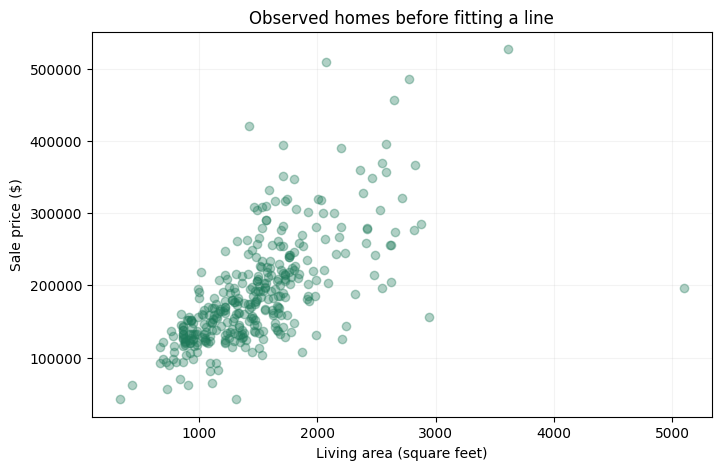

In [4]:
sample = train.sample(350, random_state=RANDOM_STATE)
plt.figure(figsize=(8, 5))
plt.scatter(sample[simple_feature], sample[target], alpha=0.35, color='#1f7a5a')
plt.xlabel('Living area (square feet)')
plt.ylabel('Sale price ($)')
plt.title('Observed homes before fitting a line')
plt.grid(alpha=0.15)
plt.show()

## 2. Create one validation design and keep it fixed

The validation homes represent unseen cases. Every model below is compared on these same rows so that the comparison is fair.

In [5]:
X = train[model_features].copy()
y = train[target].copy()

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print('Training homes:', len(X_train))
print('Validation homes:', len(X_valid))

Training homes: 2071
Validation homes: 518


## 3. Establish the median baseline

A model must improve on a credible simple rule. Here, every validation home receives the median sale price from the training data.

The notebook reports three complementary summaries:

- **MAE:** the typical absolute dollar miss;
- **RMSE:** a dollar error that gives extra weight to large misses; and
- **R²:** improvement relative to a mean-based benchmark, not a dollar error and not a causal claim.

Ordinary least squares fits coefficients using squared training residuals. That fitting objective is related to MSE and RMSE, but model selection below uses held-out validation evidence.

**Predict first:** Will a living-area model reduce the typical dollar miss by a little or a lot?

In [6]:
def regression_metrics(actual, predicted):
    return {
        'MAE': mean_absolute_error(actual, predicted),
        'RMSE': mean_squared_error(actual, predicted) ** 0.5,
        'R2': r2_score(actual, predicted)
    }

median_price = y_train.median()
baseline_predictions = np.repeat(median_price, len(y_valid))
baseline_metrics = regression_metrics(y_valid, baseline_predictions)
pd.Series(baseline_metrics, name='Median baseline').round(0)

,Median baseline
MAE,57302.0
RMSE,79581.0
R2,-0.0


## 4. Fit a simple living-area model

The coefficient reports the predicted price change for one additional square foot. It describes an association in this fitted model; it does not prove that adding a square foot causes the price change.

In [7]:
simple_model = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('model', LinearRegression())
])
simple_model.fit(X_train[[simple_feature]], y_train)
simple_predictions = simple_model.predict(X_valid[[simple_feature]])
simple_metrics = regression_metrics(y_valid, simple_predictions)

simple_coefficient = simple_model.named_steps['model'].coef_[0]
print(f'Living-area coefficient: ${simple_coefficient:,.0f} per additional square foot')
pd.Series(simple_metrics, name='Simple regression').round(0)

Living-area coefficient: $126 per additional square foot


,Simple regression
MAE,40751.0
RMSE,58950.0
R2,0.0


### Mini-interaction: change the living area

Change `example_area` and rerun the cell. Before running it, predict the direction and approximate size of the change.

In [8]:
example_area = 1800  # Change this value and rerun.
example_home = pd.DataFrame({simple_feature: [example_area]})
example_prediction = simple_model.predict(example_home)[0]
print(f'Predicted price for {example_area:,} square feet: ${example_prediction:,.0f}')

Predicted price for 1,800 square feet: $232,067


## 5. Fit a leakage-safe multiple-regression pipeline

Numeric and categorical inputs require different preparation. The pipeline learns missing-value replacements and category encodings from the training homes, then applies the same rules to validation homes.

**Predict first:** Will the multiple model improve the average home, the expensive-home segment, both, or neither?

In [9]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])
multiple_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])
multiple_model.fit(X_train, y_train)
multiple_predictions = multiple_model.predict(X_valid)
multiple_metrics = regression_metrics(y_valid, multiple_predictions)
pd.Series(multiple_metrics, name='Multiple regression').round(0)

,Multiple regression
MAE,21076.0
RMSE,35216.0
R2,1.0


In [10]:
comparison = pd.DataFrame([
    {'Model': 'Median baseline', **baseline_metrics},
    {'Model': 'Simple regression', **simple_metrics},
    {'Model': 'Multiple regression', **multiple_metrics}
]).set_index('Model')
comparison.round(0)

,MAE,RMSE,R2
Model,,,
Median baseline,57302.0,79581.0,-0.0
Simple regression,40751.0,58950.0,0.0
Multiple regression,21076.0,35216.0,1.0


## 6. Interpret selected coefficients carefully

Read each numeric coefficient as a comparison among homes with the other included features held fixed. Do not use the word *impact* or claim causality.

In [11]:
feature_names = multiple_model.named_steps['preprocess'].get_feature_names_out()
coefficients = pd.Series(
    multiple_model.named_steps['model'].coef_, index=feature_names
).sort_values(key=np.abs, ascending=False)
selected_numeric = [f'num__{name}' for name in numeric_features]
coefficients.loc[selected_numeric].rename('coefficient').round(0).to_frame()

,coefficient
num__living_area_sqft,60.0
num__overall_quality,13825.0
num__year_built,253.0
num__bedrooms,-6459.0
num__full_bathrooms,-536.0
num__garage_capacity,10989.0
num__basement_sqft,23.0


## 7. Diagnose residuals and segment risk

A metric summarizes error. A residual plot shows whether the errors have a pattern. A credible model should not systematically miss the same kinds of homes.

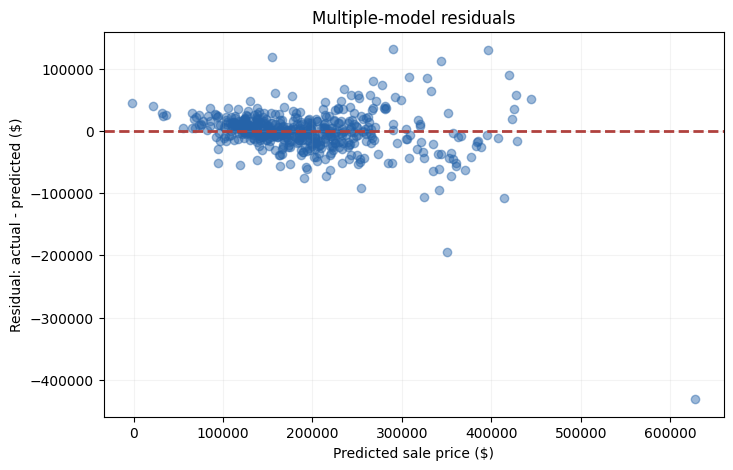

In [12]:
residuals = y_valid.to_numpy() - multiple_predictions
plt.figure(figsize=(8, 5))
plt.scatter(multiple_predictions, residuals, alpha=0.45, color='#2563a9')
plt.axhline(0, color='#b0413e', linestyle='--', linewidth=2)
plt.xlabel('Predicted sale price ($)')
plt.ylabel('Residual: actual - predicted ($)')
plt.title('Multiple-model residuals')
plt.grid(alpha=0.15)
plt.show()

In [15]:
high_price_cutoff = y_valid.quantile(0.80)
high_price_mask = y_valid >= high_price_cutoff
segment_results = pd.DataFrame({
    'Segment': ['All validation homes', 'Highest-price 20%'],
    'Homes': [len(y_valid), int(high_price_mask.sum())],
    'MAE': [
        mean_absolute_error(y_valid, multiple_predictions),
        mean_absolute_error(y_valid[high_price_mask], multiple_predictions[high_price_mask])
    ],
    'Mean residual': [
        residuals.mean(),
        residuals[high_price_mask.to_numpy()].mean()
    ]
})
segment_results.round(0)

,Segment,Homes,MAE,Mean residual
0,All validation homes,518,21076.0,-1142.0
1,Highest-price 20%,104,35398.0,11151.0


## 8. Make the clinic decision

Choose **advance simple**, **advance multiple**, or **require more evidence**.

Your four-bullet coefficient memo must include:

1. one coefficient interpreted in business units;
2. one validation metric compared with the median baseline;
3. one residual or segment risk; and
4. one safe claim, unsafe claim, or next test.

Save the notebook. The polished Exercise 01 submission comes later.

## 8. Make the clinic decision

**Decision: advance the multiple regression** to Section 9, refit on
`log(sale_price)` so predictions are strictly positive and the loss
aligns with the RMSLE metric.


- **Coefficient in business units.** `overall_quality`
    -  adds **+$13,830 per one-point increase**, holding all other features constant. This is the strongest lever in the model.

- **Validation vs. baseline.** MAE drops from **$57,302 (baseline) to
  $21,076 (multiple)** on 518 held-out homes — a **63% reduction**.
  R² rises from −0.06 to 0.79.

- **Segment risk.** The top-20% price segment (homes ≥ $244,753) has
  MAE $35,398.
  - mean residual +$11,151
  
   (residual = actual − predicted,
  so a positive value means the model **under-predicts**). The model
  systematically **under-values expensive homes** by ~$11k on average.
  This is its weakest operating region.

- **Safe / unsafe / next test.**
  
  *Safe:* screening tool for mid-market
  homes below the 80th percentile.
  
  *Unsafe:* replacing appraisal for
  luxury homes.
  
  *Next test:* refit on `log(sale_price)` and confirm
  zero negative predictions before generating `submission.csv`.

## 9. Exercise continuation and final submission

After the clinic, revisit the full problem brief. You may revise the feature set and model, but preserve a leakage-safe split, compare against a baseline, and document why the final model is appropriate.

In [16]:
# ---- Section 9: final model, predictions, submission ----

final_features = numeric_features + categorical_features

final_numeric = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])
final_categorical = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
final_preprocessor = ColumnTransformer(transformers=[
    ('num', final_numeric, numeric_features),
    ('cat', final_categorical, categorical_features)
])
final_model = Pipeline(steps=[
    ('preprocess', final_preprocessor),
    ('model', LinearRegression())
])

final_model.fit(train[final_features], np.log(train[target]))

log_predictions = final_model.predict(test[final_features])
predictions = np.exp(log_predictions)

assert (predictions > 0).all(), "All predictions must be positive"
assert np.isfinite(predictions).all(), "All predictions must be finite"

submission = pd.DataFrame({
    'property_id': test['property_id'],
    'predicted_sale_price': predictions
})
submission.to_csv('../submission.csv', index=False)

print(f"Wrote {len(submission)} predictions to ../submission.csv")
print()
print("First 5 rows:")
print(submission.head().to_string(index=False))
print()
print("Prediction summary:")
print(submission['predicted_sale_price'].describe().round(0).to_string())

Wrote 341 predictions to ../submission.csv

First 5 rows:
property_id  predicted_sale_price
HOME-101571         148040.644434
HOME-102860         256393.056228
HOME-101622         176260.565117
HOME-101461         146951.079999
HOME-100264         211306.485948

Prediction summary:
count       341.0
mean     181309.0
std       69561.0
min       73731.0
25%      134167.0
50%      163617.0
75%      216917.0
max      487958.0


### Model Choice: Multiple linear regression on log(sale_price)

Im keeping the same features from section 5, but I will change fitness on "log(sale_price) instead of "sale_price".

For two reasons:

The price distribution is very skewed to the right. Taking the log makes the model more symmetric. My audit is verified with section 1 showing skewedness dropping from 1.76 to 0.06.

The second reason is this exercise uses RMSLE, measuring error on the log scale. Fitting the model on log-prices, which is quite close to the actual scoring rule.

## Generative AI use disclosure

Complete the disclosure specified in `../../shared/ai_use_disclosure.md`.